<a href="https://colab.research.google.com/github/MaxHolikov/DataScience/blob/main/hw6/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лог-файл успешно очищен.
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null  

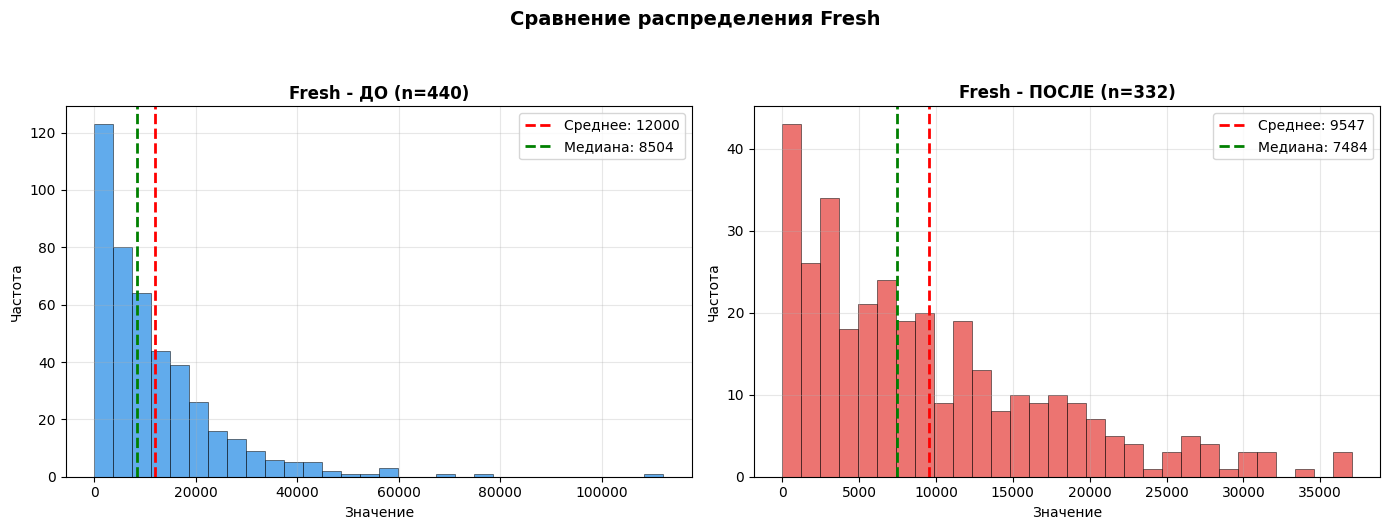

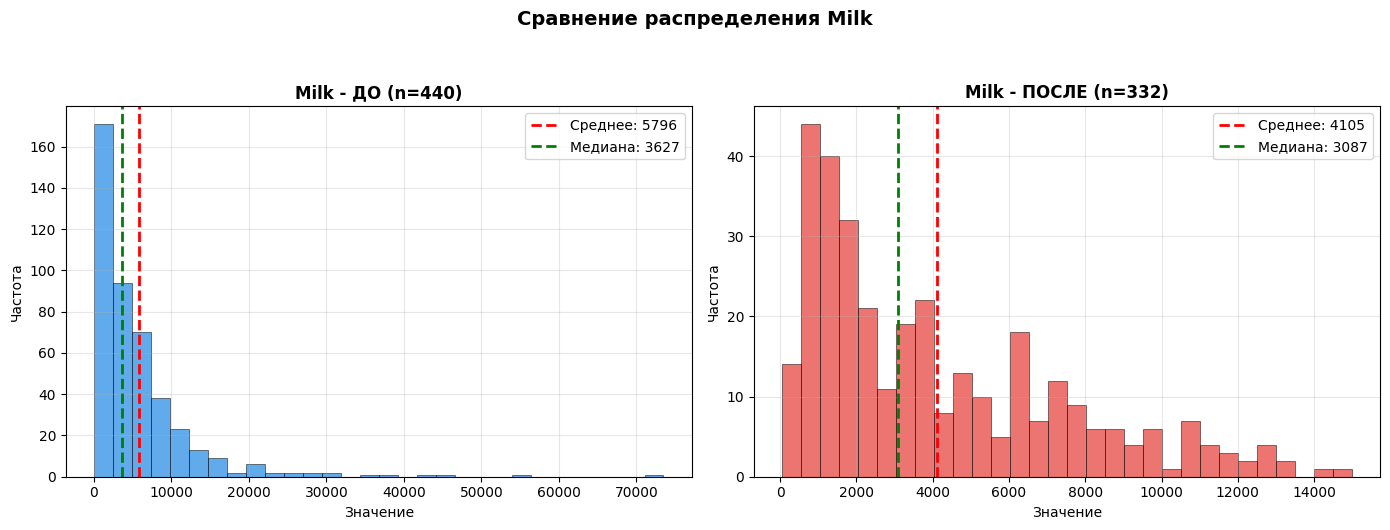

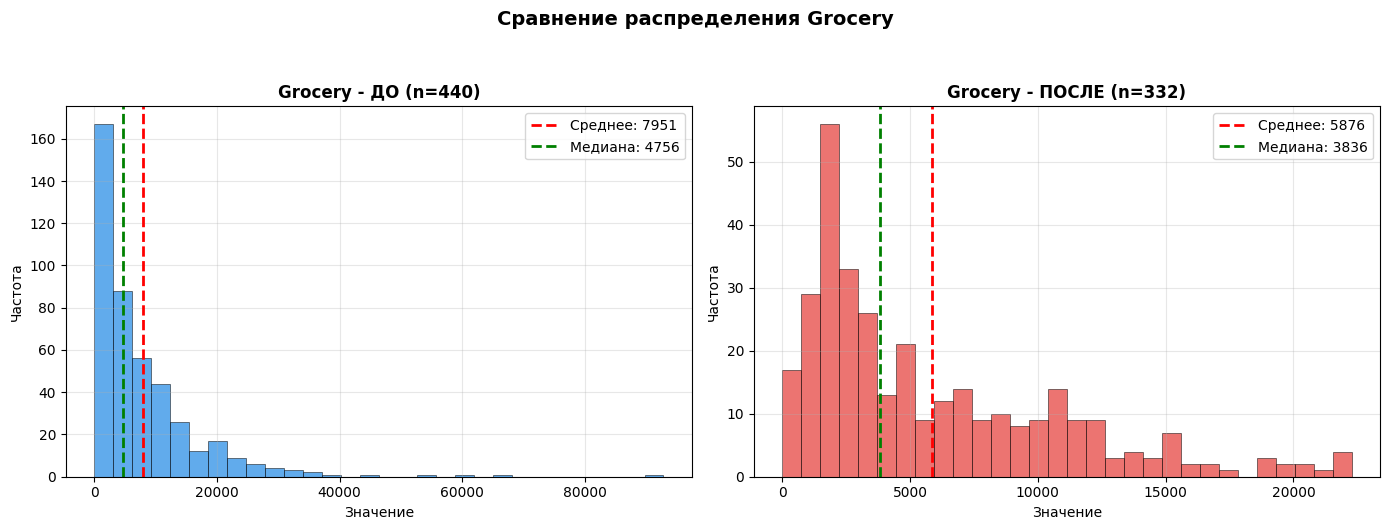

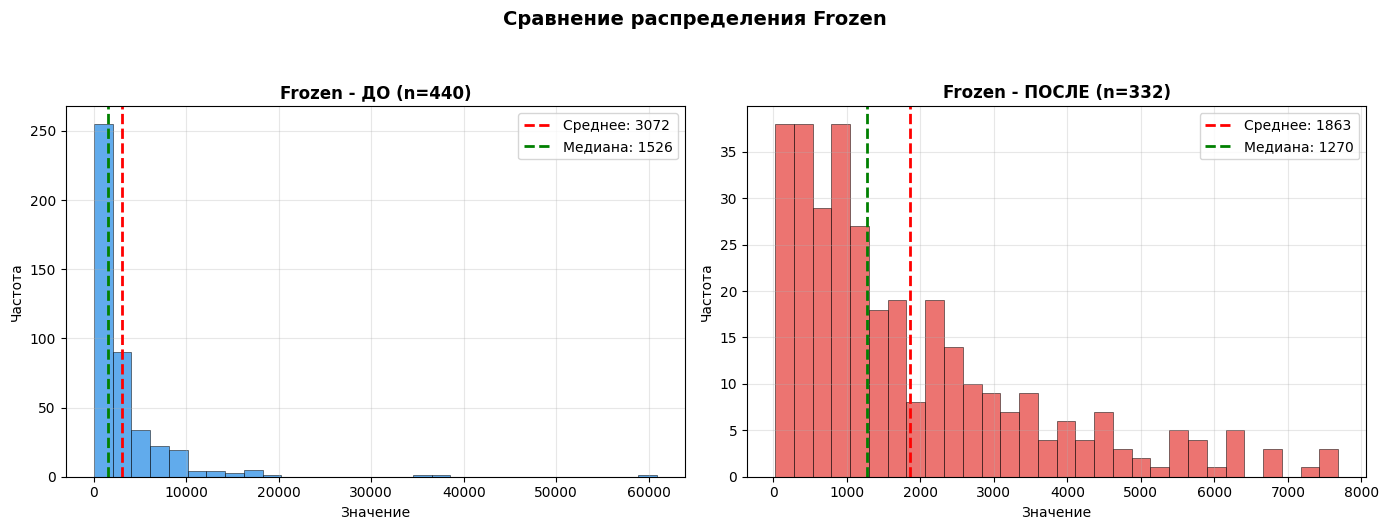

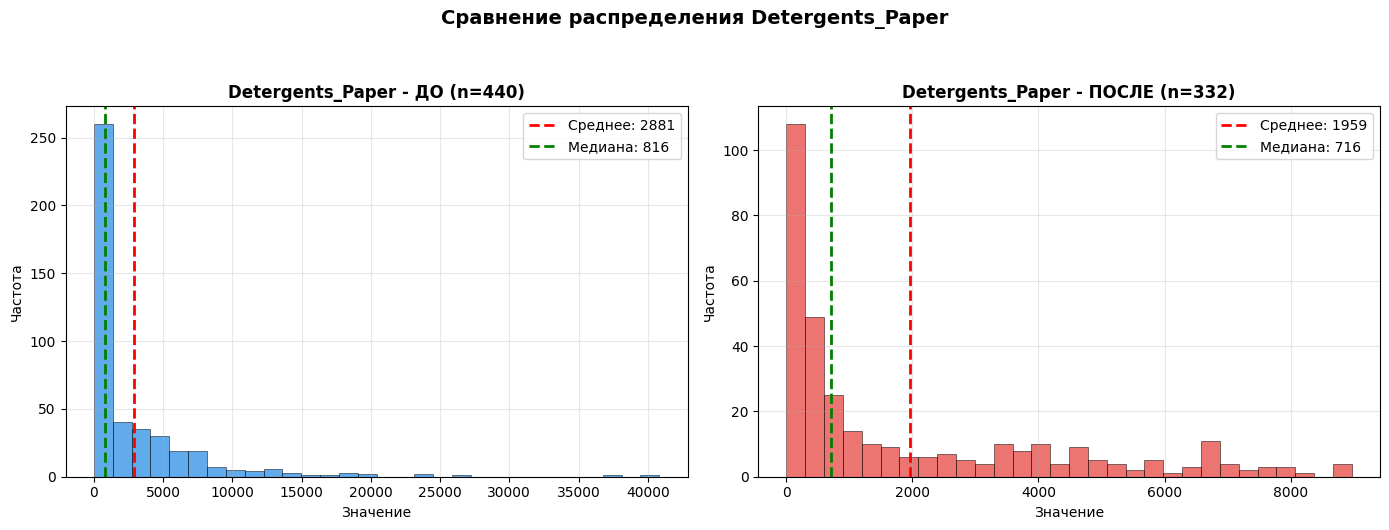

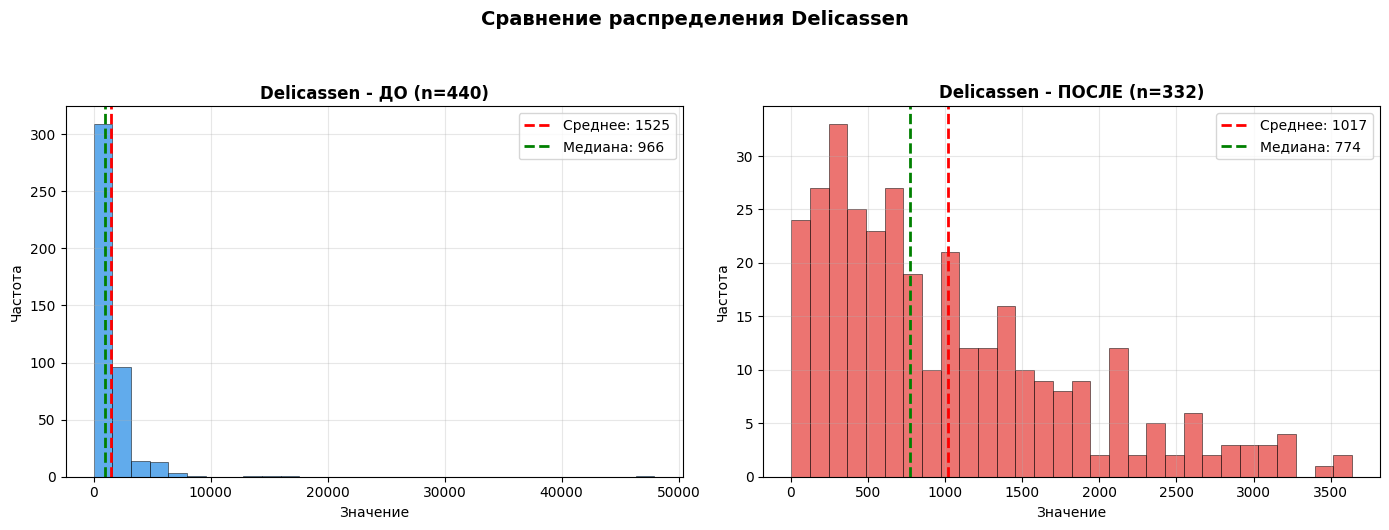

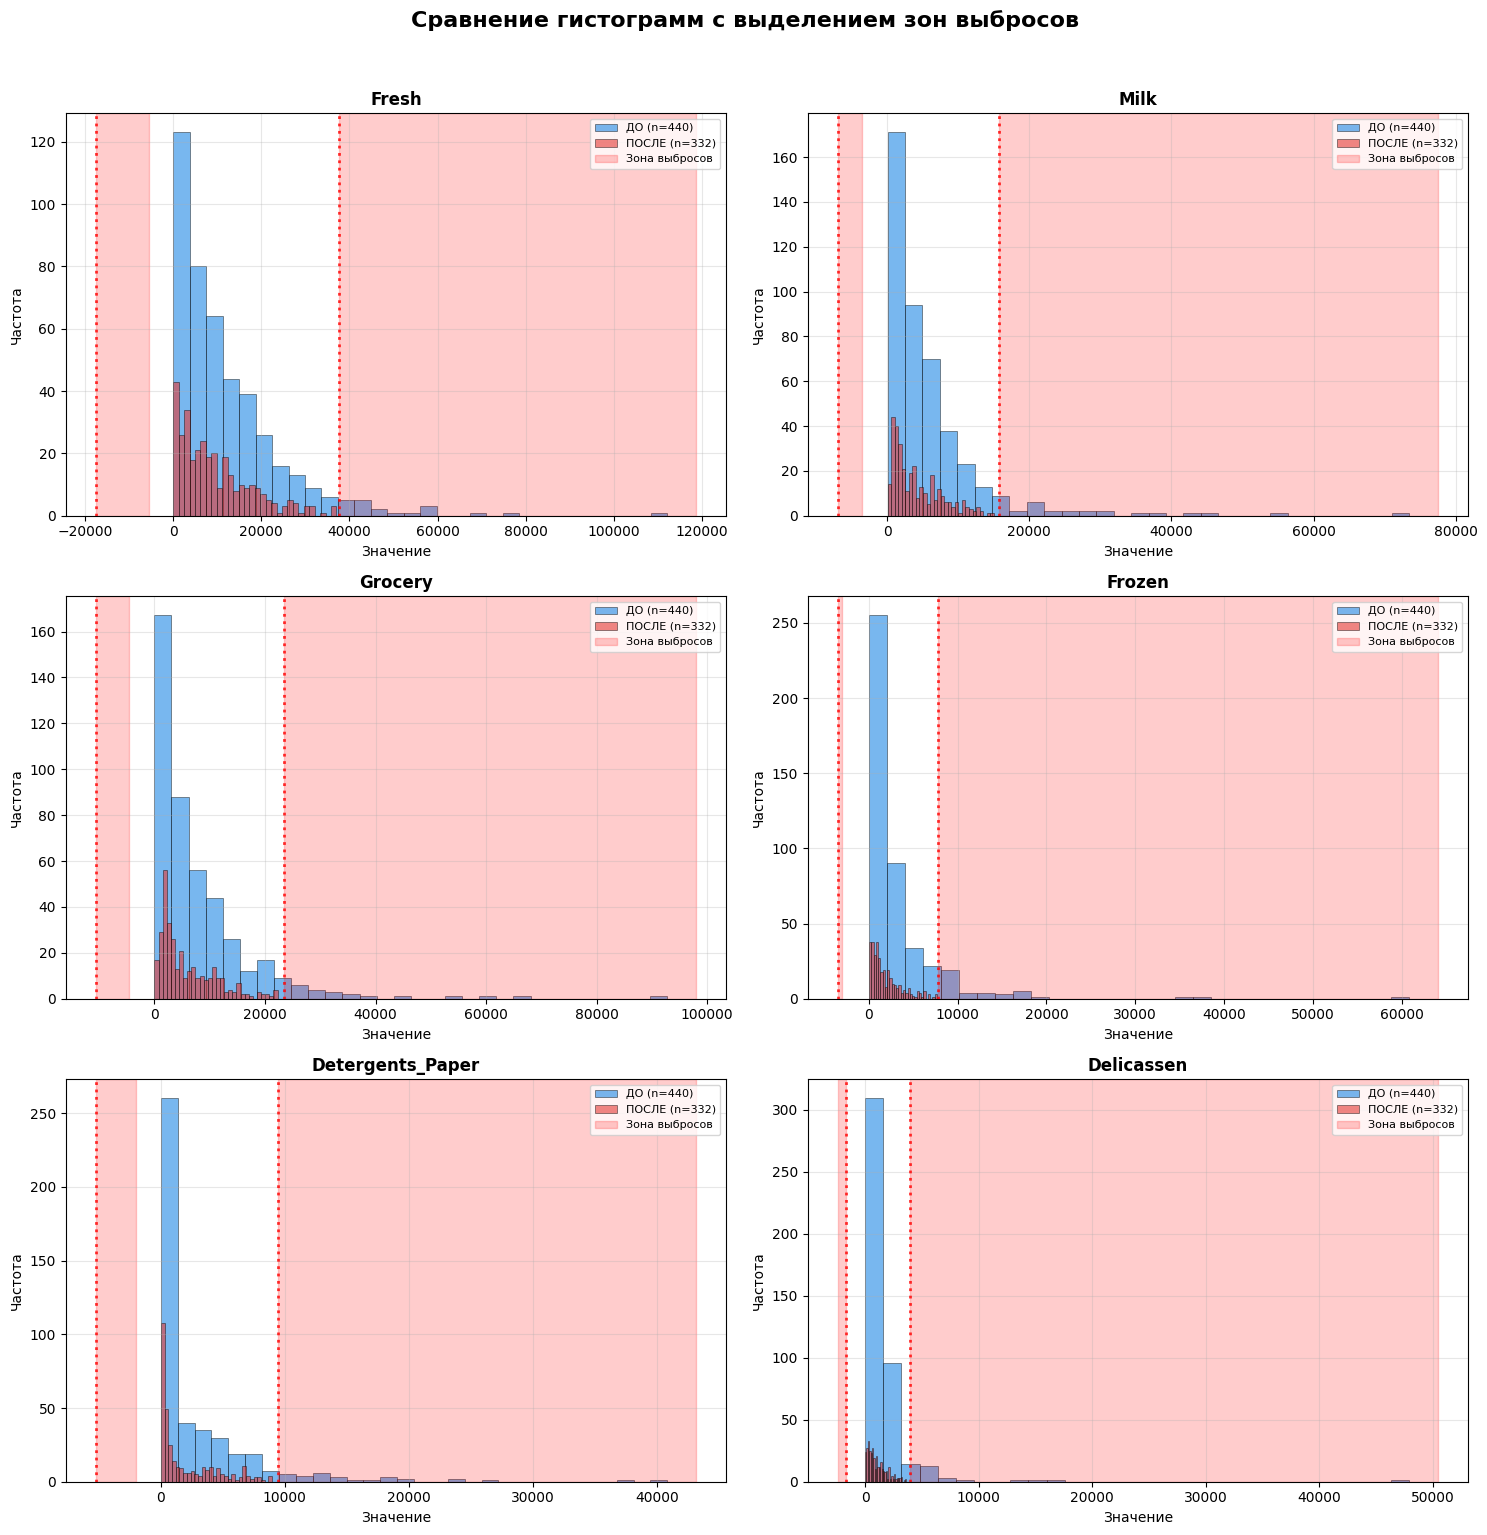

Строим график ДО удаления выбросов...
Строим график ПОСЛЕ удаления выбросов...


<Figure size 3000x1200 with 0 Axes>

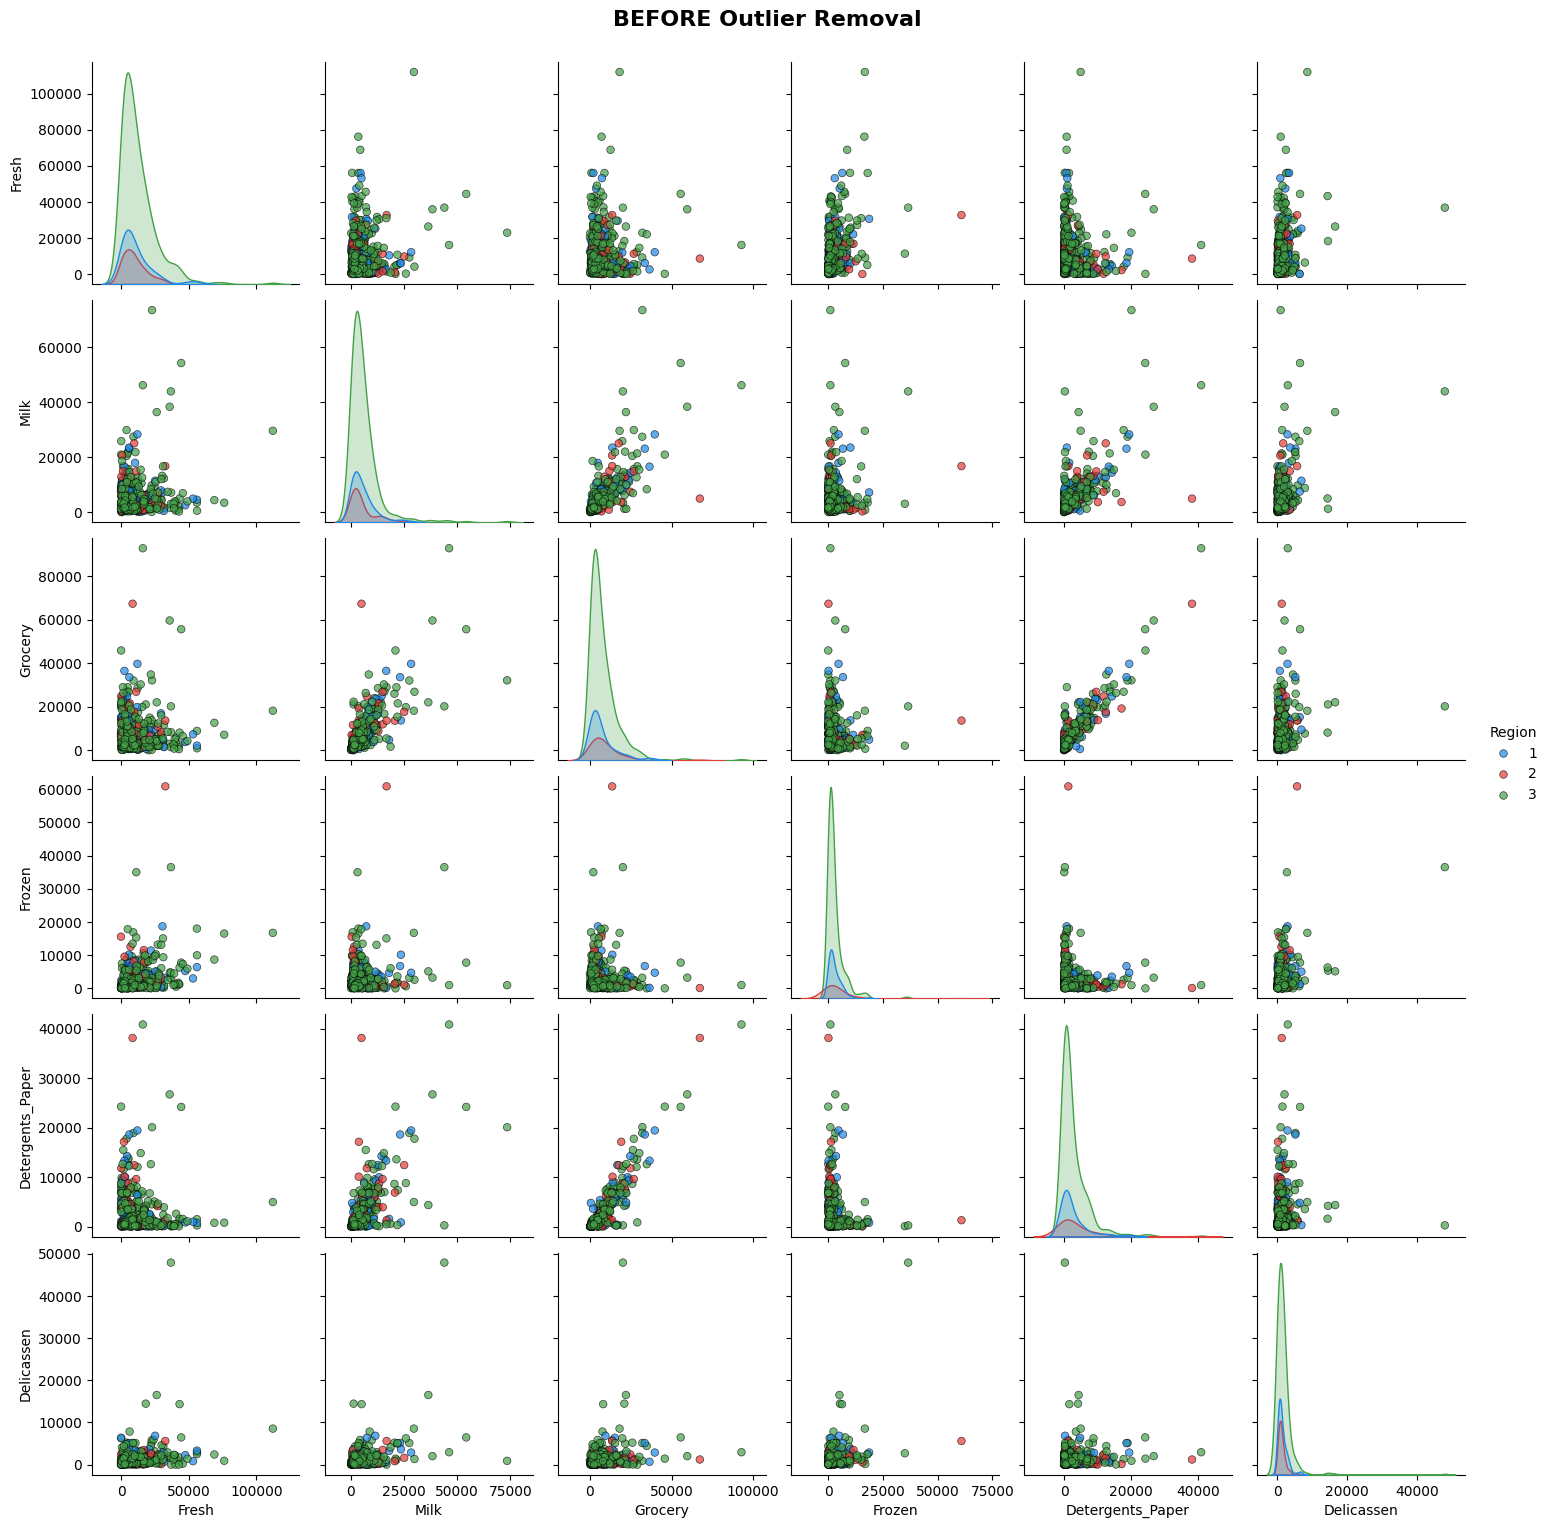

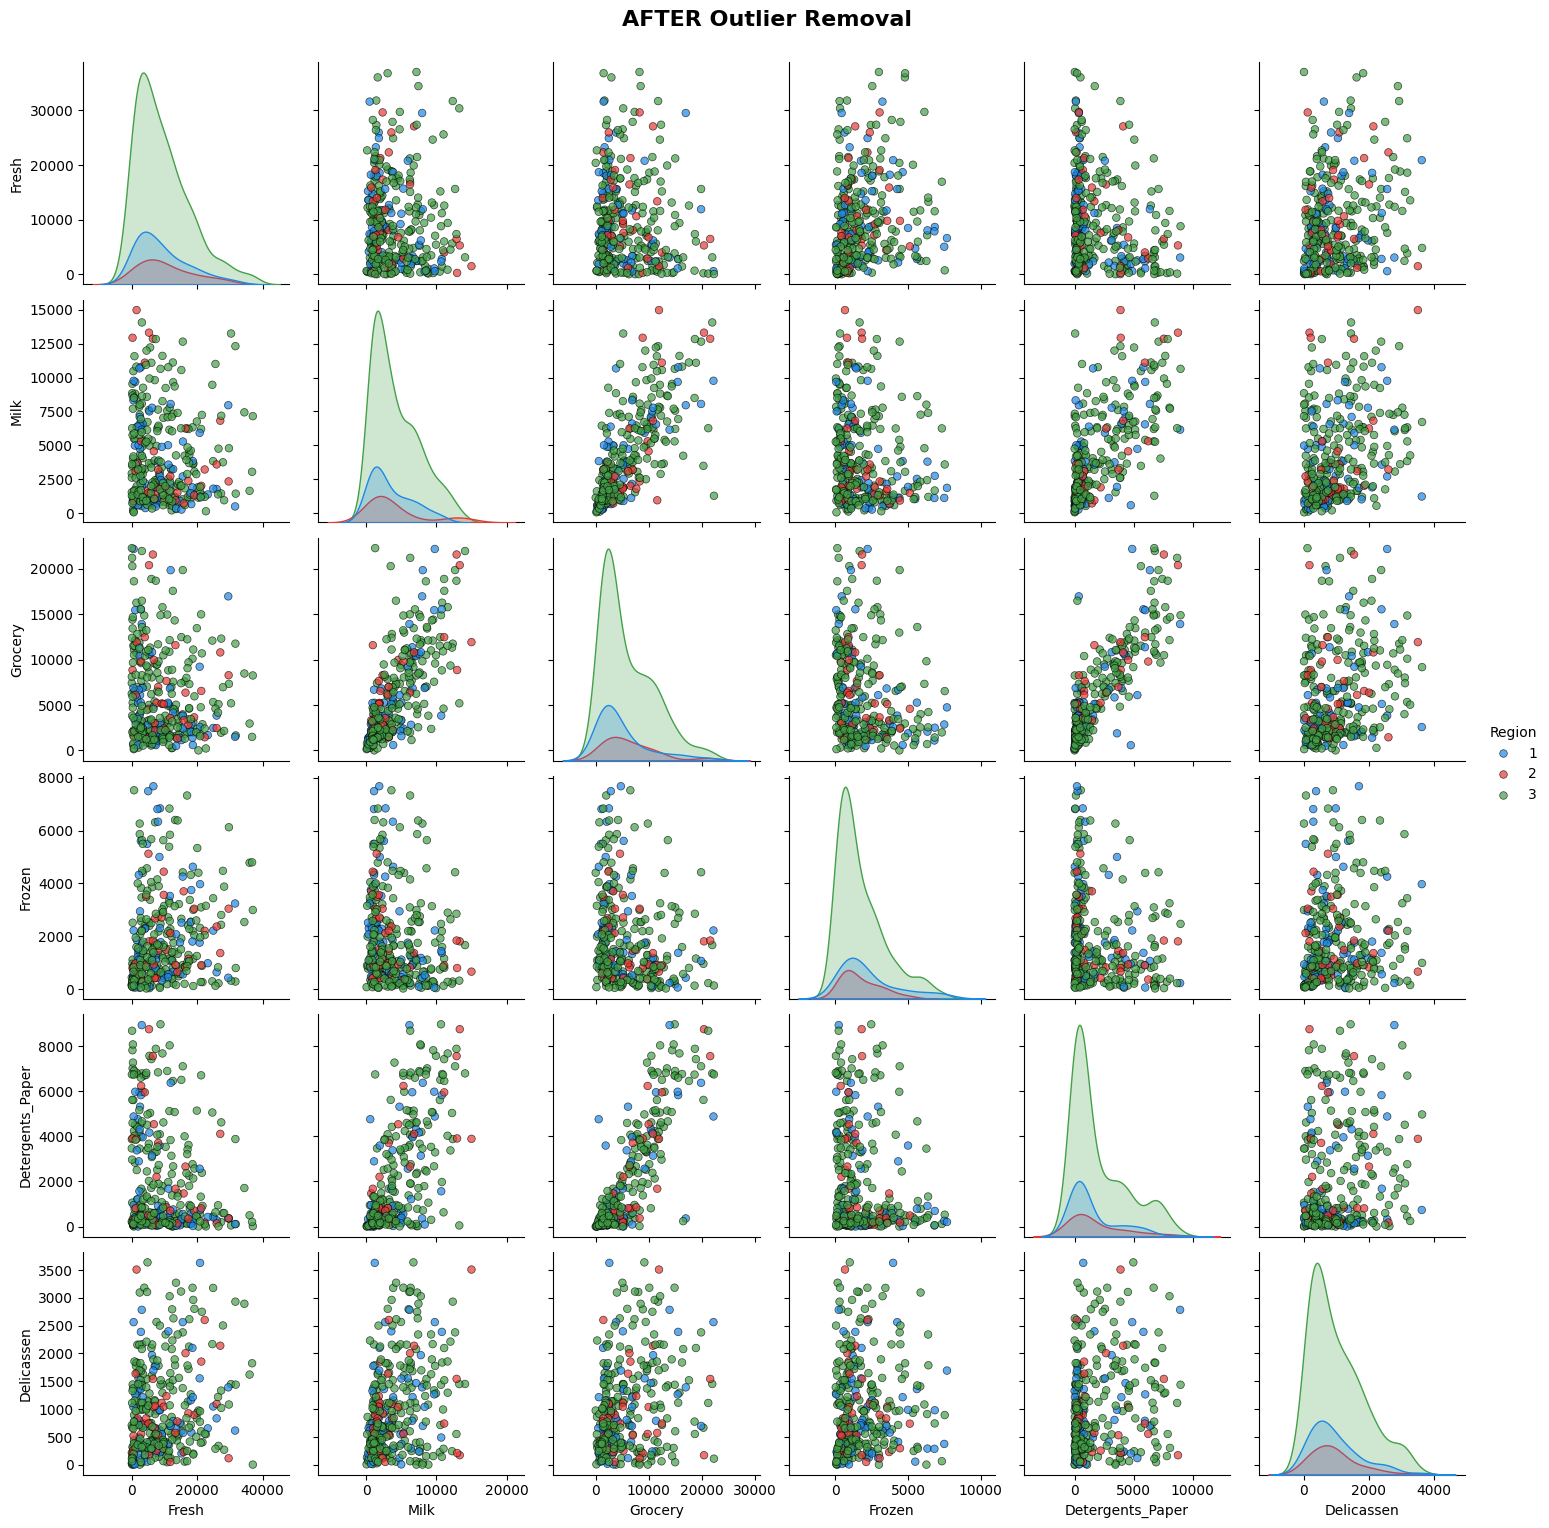


Сравнение завершено. Прокрутите вверх, чтобы увидеть оба графика.


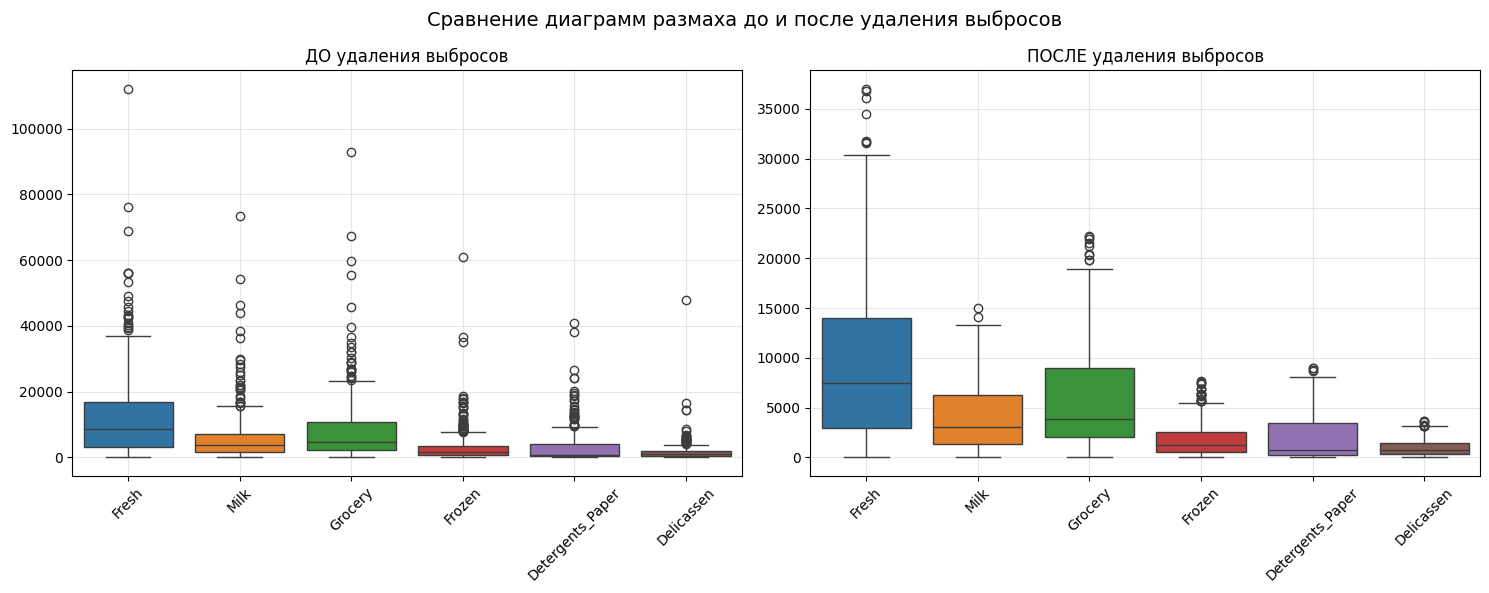

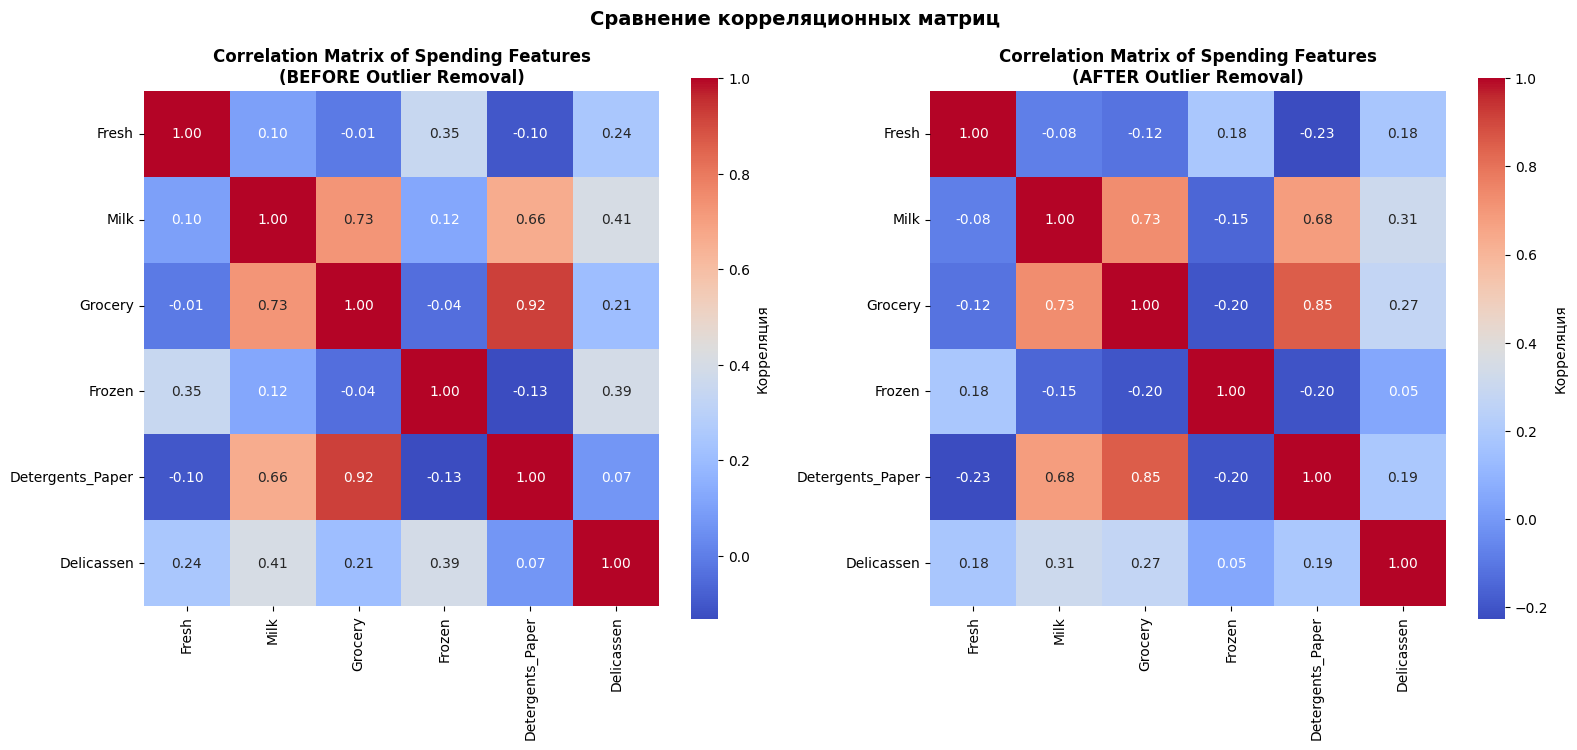

Содержимое лог-файла:
2026-03-15 03:12:57 - INFO - File: .csv загружен
2026-03-15 03:12:57 - INFO - Количество пропущенных значений в датасете: 0
2026-03-15 03:12:57 - INFO - Размер датасета:440 строк x 8 колонок
2026-03-15 03:12:57 - INFO - Пропущенных значений: 0
2026-03-15 03:12:57 - INFO - Дубликатов: 0
2026-03-15 03:12:57 - INFO - Starting outlier removal using IQR method.
2026-03-15 03:12:57 - INFO - Removed 108 rows (initial: 440, remaining: 332) after IQR outlier treatment.
2026-03-15 03:12:57 - INFO - Датасет без выбросов сохранен в 'wholesale_customers_cleaned.csv'


In [1]:
import get_dataset as gd
import logger as lg
from data_processing import DataProcessing
import functions as fun
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lg.clear_log_file()

my_results_dict = {}

file_path='Wholesale customers data.csv'

try:
    df = pd.read_csv(file_path)
    lg.log_event("INFO", "File: .csv загружен" )
except FileNotFoundError:
    lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

# --- Data Processing and Missing Values ---
processing = DataProcessing(df)
processing.print_file()
missing_values = processing.count_missing()   # количество пропущенных значений
processing.missing_report()

if missing_values > 0:
  print(f"Количество пропущенных значений: {missing_values} \n")
  lg.log_event("INFO", f"Количество пропущенных значений: {missing_values}" )
  processing.missing_report()
  processing.fill_missing('mean')  #заполнение пустых ячеек
  processing.missing_report()
  missing_values = processing.count_missing()
  print(f"Колличество пропущенных значений в датасете: {missing_values}\n")
  print('=================')
  lg.log_event("INFO", f"Количество пропущенных значений после обработки: {processing.count_missing()}" )

else:
  lg.log_event("INFO", f"Количество пропущенных значений в датасете: {processing.count_missing()}" )

report = processing.create_eda_report()
print(report)

# -------------------------------------------------------------------

# Columns to apply outlier removal. Exclude 'Channel' and 'Region' as they are categorical.
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# --- Store Original DataFrame for 'Before' Visualizations ---
df_original = df.copy()

# --- Apply Outlier Removal ---
lg.log_event("INFO", "Starting outlier removal using IQR method.")
df_cleaned = fun.remove_outliers_iqr(df_original.copy(), spending_cols) # Pass a copy to avoid modifying original df_original if not intended
df_cleaned.to_csv('wholesale_customers_cleaned.csv', index=False)
lg.log_event("INFO", f"Датасет без выбросов сохранен в 'wholesale_customers_cleaned.csv'" )
# Update df to the cleaned version for subsequent processing
df = df_cleaned.copy()

# 1. Statistics
fun.print_histogram_statistics_comparison(df_original, df_cleaned)

# 2. Histograms
fun.compare_single_histogram(df_original, df_cleaned, 'Fresh')
fun.compare_single_histogram(df_original, df_cleaned, 'Milk')
fun.compare_single_histogram(df_original, df_cleaned, 'Grocery')
fun.compare_single_histogram(df_original, df_cleaned, 'Frozen')
fun.compare_single_histogram(df_original, df_cleaned, 'Detergents_Paper')
fun.compare_single_histogram(df_original, df_cleaned, 'Delicassen')

# ВАРИАНТ 3: С плотностью распределения
#fun.compare_density_histograms(df_original, df_cleaned, spending_cols)

# ВАРИАНТ 4: С выделением зон выбросов
fun.compare_with_outliers_highlight(df_original, df_cleaned, spending_cols)

# 5. Pairplot
fun.compare_pairplots_subplots(df_original, df_cleaned, spending_cols, hue='Region')

# 6. Boxplot
fun.boxplot(df_original, df_cleaned, spending_cols)

# 7. Correlation Matrix
fun.matrix_cor(df_original, df_cleaned, spending_cols)

if __name__ == "__main__":
  lg.read_log_file()


Лог-файл успешно очищен.
Лог-файл успешно очищен.

ЗАГРУЗКА ДАННЫХ
   Файл загружен: wholesale_customers_cleaned.csv
   Размер: (332, 8)
   Колонки: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

ПОДГОТОВКА ДАННЫХ
   Данные подготовлены
   Размер: (332, 6)
   Признаки: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
   Среднее после нормализации: [-0.  0.  0. -0.  0. -0.]
   Стандартное отклонение: [1. 1. 1. 1. 1. 1.]

ПОИСК АНОМАЛИЙ (5+ МЕТОДОВ)
Размер данных: 332 записей
Параметр contamination: 0.1

 Isolation Forest...
    Найдено аномалий: 34 (10.24%)

 Local Outlier Factor...
    Найдено аномалий: 34 (10.24%)

 One-Class SVM...
    Найдено аномалий: 36 (10.84%)

 Elliptic Envelope...
    Найдено аномалий: 34 (10.24%)

 DBSCAN...
   Найдено кластеров: 2
   Найдено аномалий (шум): 291 (87.65%)

------------------------------------------------------------
   СОГЛАСОВАННОСТЬ МЕТОДОВ:
   Всего записей: 332
   Аном

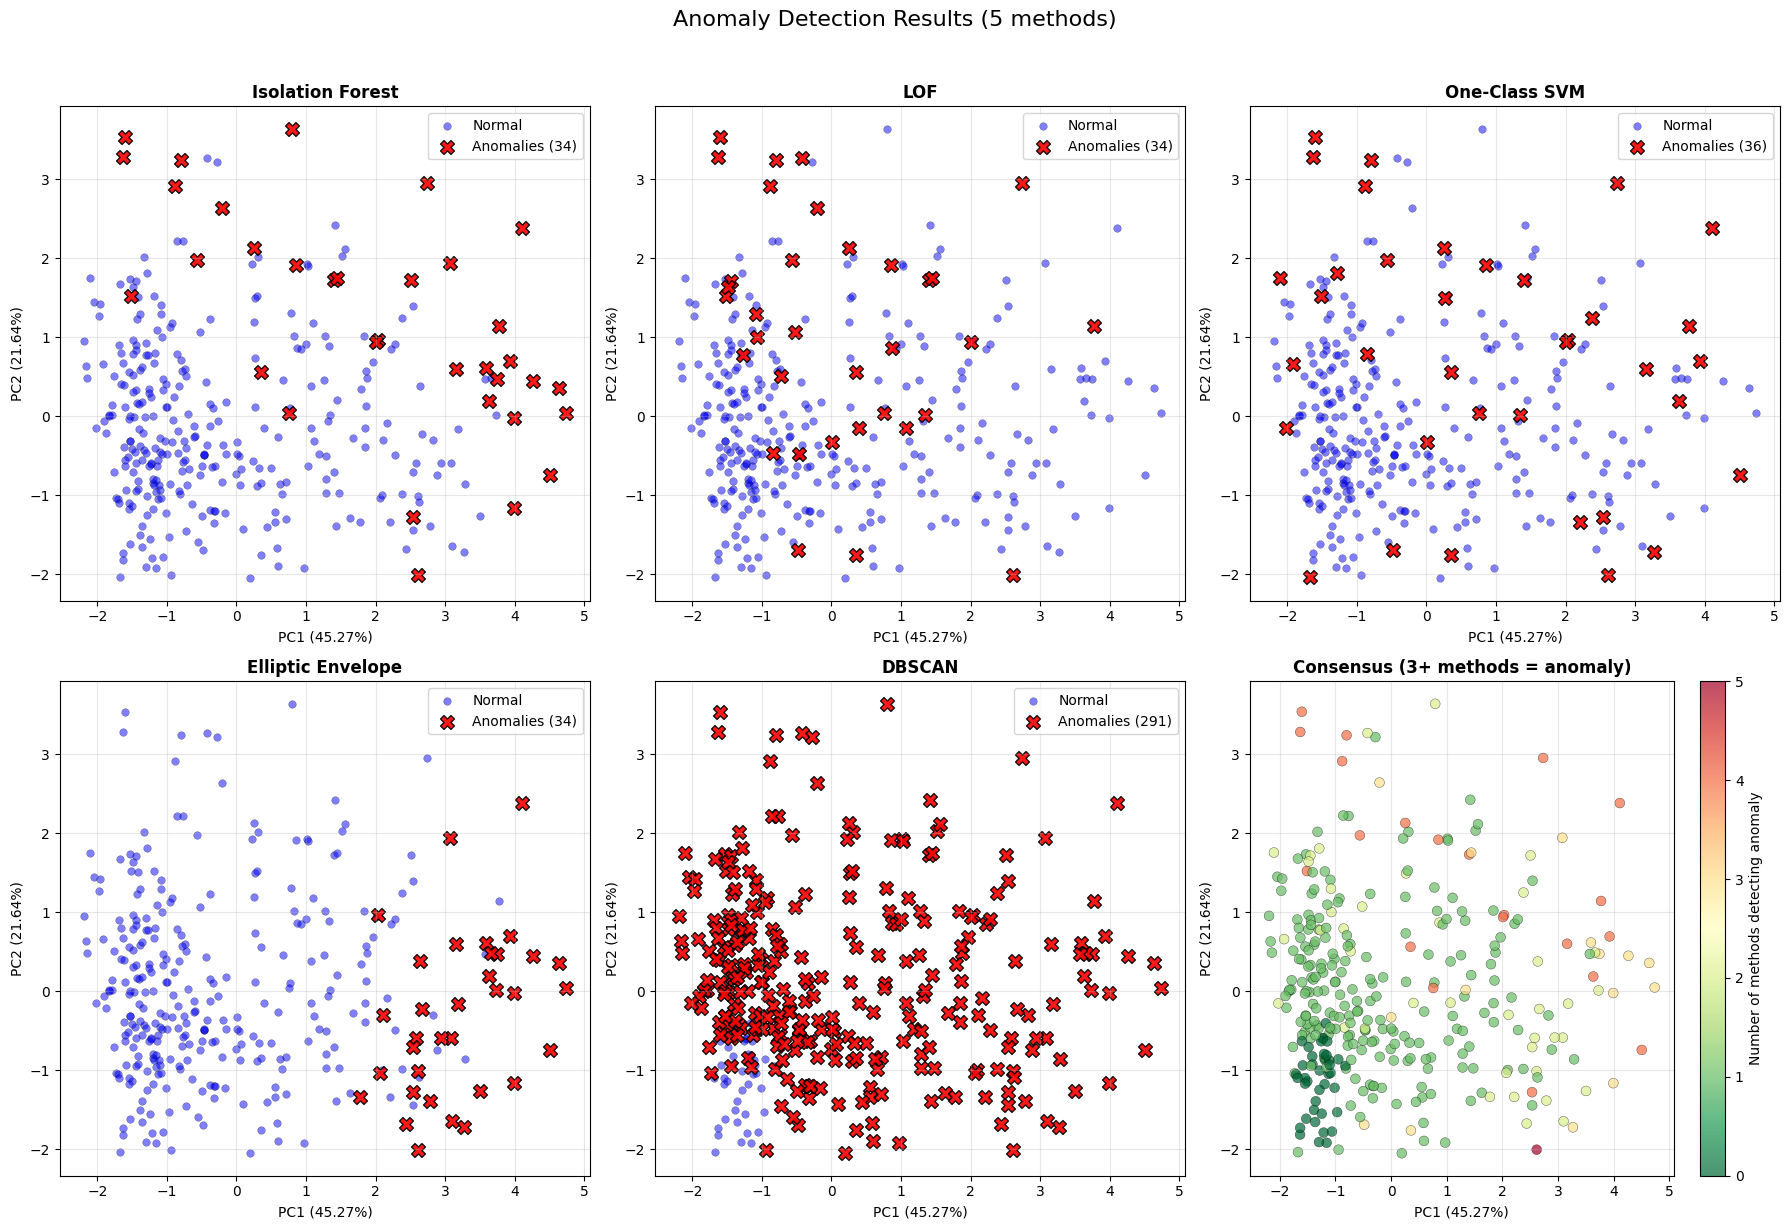


 График 2: Распределение аномалий по признакам...


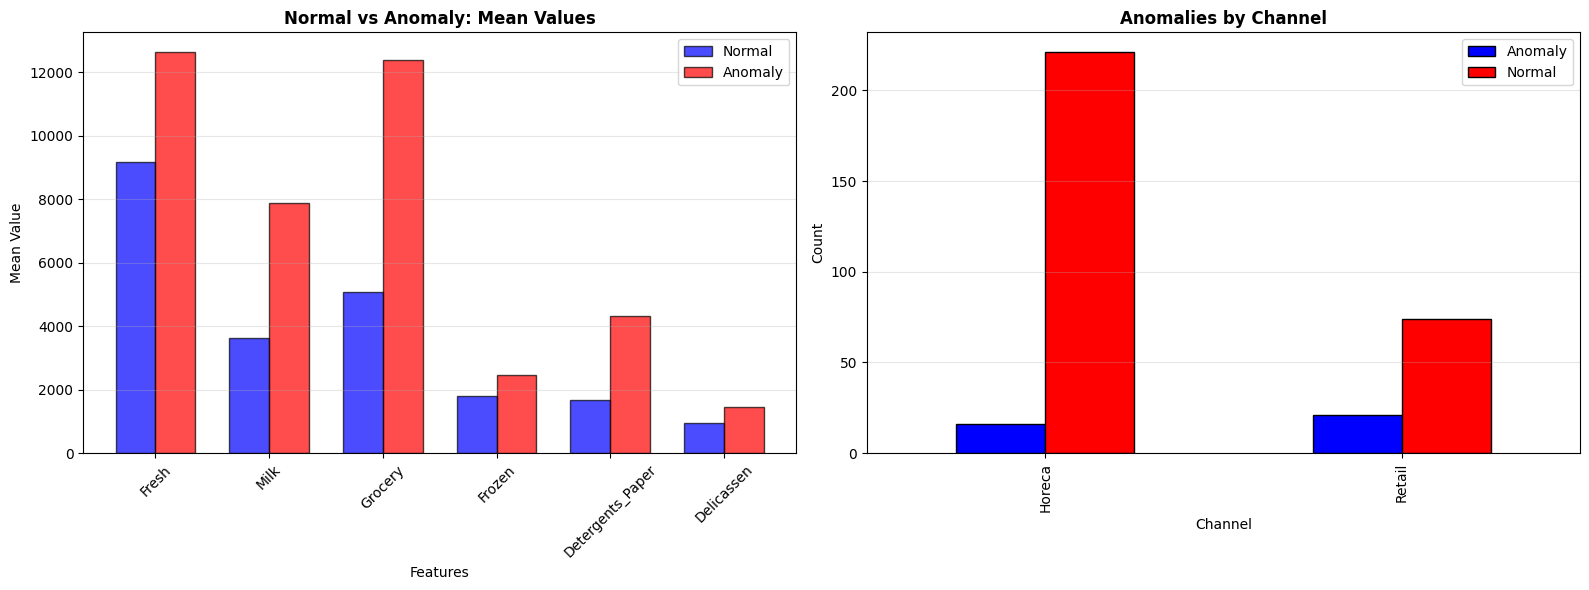


 График 3: Распределение аномальных оценок...


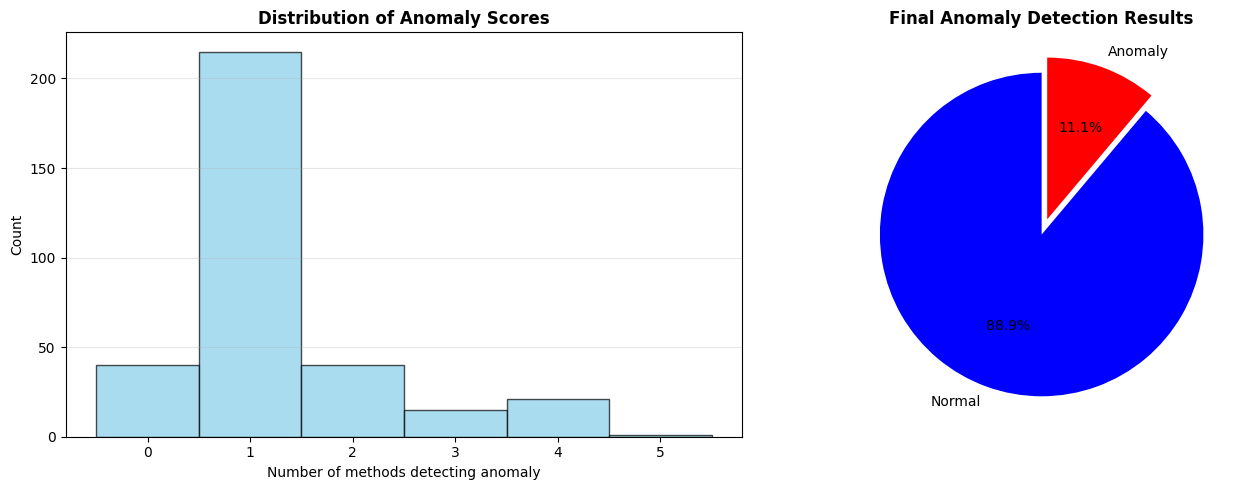


 График 4: Детальный показ аномальных записей...
Всего аномалий: 37

Топ-5 аномальных записей:
    Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Anomaly_Score  Is_Anomaly
7         2       3   6006  11093    18881    1159              7425        2098            3.0        True
10        2       3  31714  12319    11757     287              3881        2931            4.0        True
11        2       3  21217   6208    14982    3095              6707         602            4.0        True
25        1       3  29729   4786     7326    6130               361        1083            4.0        True
32        2       3   3103  14069    21955    1668              6792        1452            3.0        True


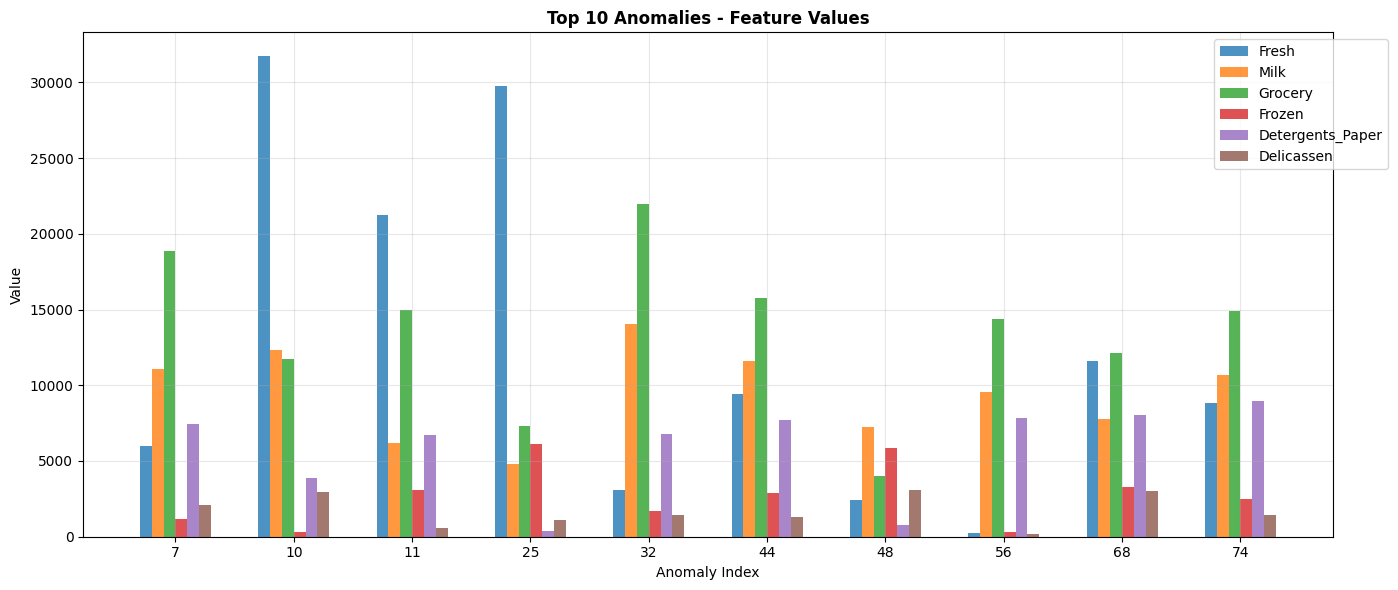


 График 5: Корреляция признаков с аномалиями...


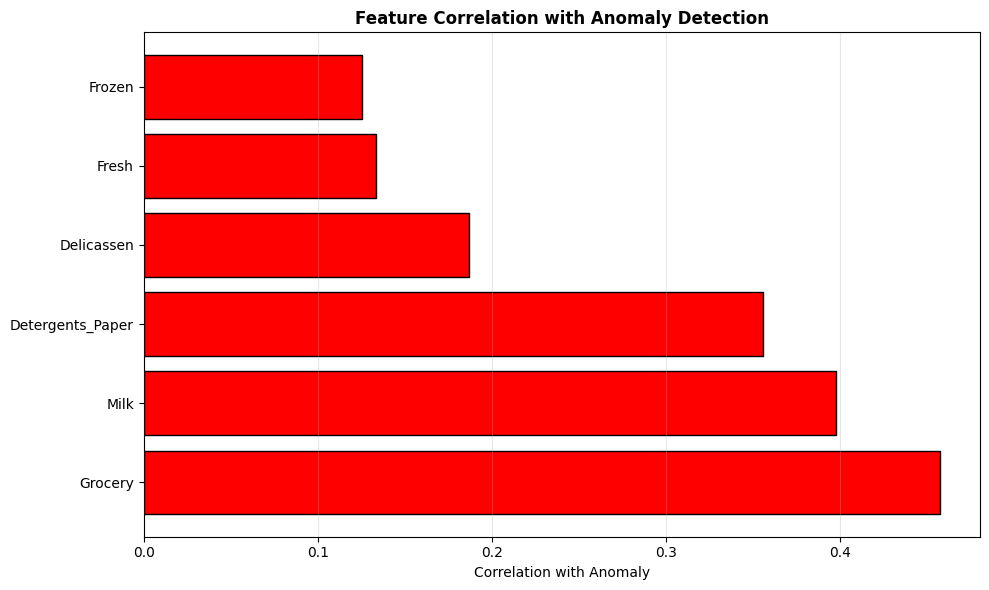


 График 6: Профиль аномальных записей...


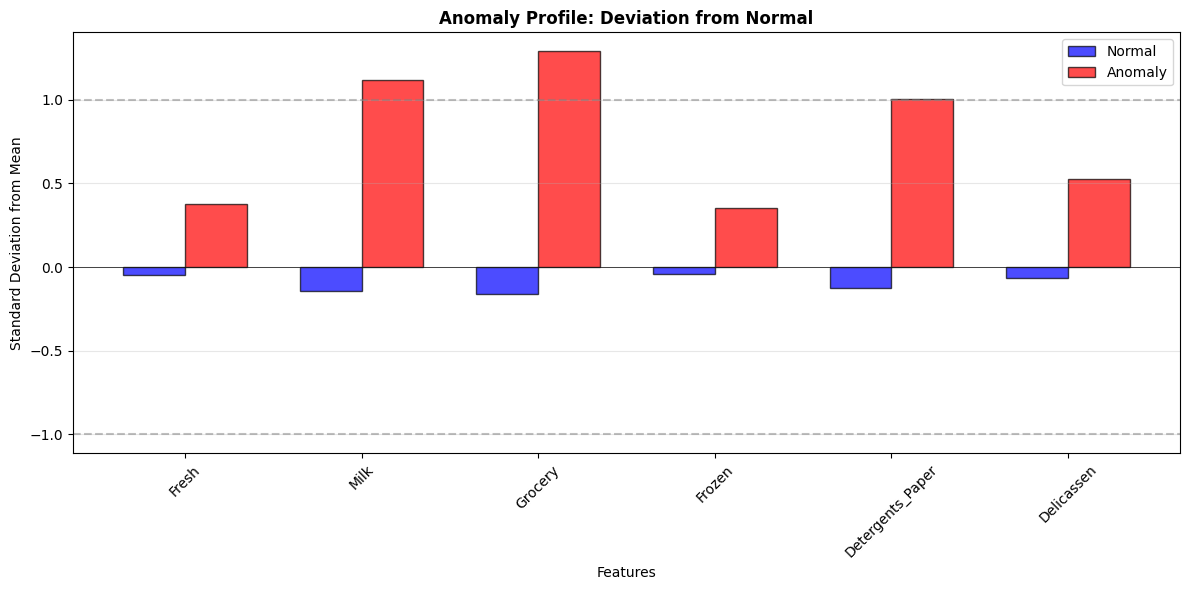


 Результаты сохранены в wholesale_with_anomalies.csv

ИТОГОВЫЙ ОТЧЕТ ПО АНОМАЛИЯМ

Всего записей: 332
Нормальные записи: 295 (88.9%)
Аномальные записи: 37 (11.1%)

МЕТОДЫ ОБНАРУЖЕНИЯ:

    • Isolation Forest: 34 аномалий
    • LOF: 34 аномалий
    • One-Class SVM: 36 аномалий
    • Elliptic Envelope: 34 аномалий
    • DBSCAN: 291 аномалий

СОГЛАСОВАННОСТЬ:
    • Обнаружены 3+ методами: 37
    • Обнаружены 2 методами: 40
    • Обнаружены 1 методом: 215


 Анализ завершен!
 Ключи в my_results_dict: ['anomaly_results', 'df_with_anomalies', 'detector']


In [2]:
import get_dataset as gd
import logger as lg
from analyser import (SegmentationAnalysis, OptimalKFinder,
                     ClusteringAlgorithms, ClusteringVisualizer, FeatureImportanceAnalyzer)
from anomaly import AnomalyDetection, AnomalyDetector, AnomalyVisualizer
import pandas as pd
import numpy as np

lg.clear_log_file()

# Создаем словарь для результатов
my_results_dict = {}
#file_path = 'Wholesale customers data.csv'
file_path = 'wholesale_customers_cleaned.csv'
df = pd.read_csv(file_path)

try:
    df = pd.read_csv(file_path)
    lg.log_event("INFO", "File: .csv загружен" )
except FileNotFoundError:
    lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

# 1. Создаем объект AnomalyDetection
anomaly = AnomalyDetection(file_path)

# 2. Подготавливаем данные
anomaly.prepare_data()

# 3. Создаем детектор и обнаруживаем аномалии
detector = AnomalyDetector(anomaly)
results = detector.detect_all_methods(contamination=0.1)

# 4. Сохраняем результаты в словарь
my_results_dict['anomaly_results'] = {
    'consensus': detector.consensus,
    'consensus_anomalies': detector.consensus_anomalies,
    'n_anomalies': np.sum(detector.consensus_anomalies),
    'results_by_method': {name: np.sum(mask) for name, mask in detector.results.items()}
}

# 5. Визуализация
visualizer = AnomalyVisualizer(detector)
visualizer.plot_all_graphs()

# 6. Сохраняем датасет с метками аномалий
output_file = 'wholesale_with_anomalies.csv'
anomaly.df.to_csv(output_file, index=False)
print(f"\n Результаты сохранены в {output_file}")

# 7. Итоговый отчет
print("\n" + "=" * 80)
print("ИТОГОВЫЙ ОТЧЕТ ПО АНОМАЛИЯМ")
print("=" * 80)

n_anomalies = np.sum(detector.consensus_anomalies)
n_normal = len(anomaly.df) - n_anomalies

print(f"""
Всего записей: {len(anomaly.df)}
Нормальные записи: {n_normal} ({n_normal/len(anomaly.df)*100:.1f}%)
Аномальные записи: {n_anomalies} ({n_anomalies/len(anomaly.df)*100:.1f}%)

МЕТОДЫ ОБНАРУЖЕНИЯ:
""")

for name, mask in detector.results.items():
    print(f"    • {name}: {np.sum(mask)} аномалий")

print(f"""
СОГЛАСОВАННОСТЬ:
    • Обнаружены 3+ методами: {np.sum(detector.consensus >= 3)}
    • Обнаружены 2 методами: {np.sum(detector.consensus == 2)}
    • Обнаружены 1 методом: {np.sum(detector.consensus == 1)}
""")

lg.log_event("INFO", f"Anomaly detection completed: {n_anomalies} anomalies found")

# Сохраняем в my_results_dict
my_results_dict['df_with_anomalies'] = anomaly.df
my_results_dict['detector'] = detector

print("\n Анализ завершен!")
print(f" Ключи в my_results_dict: {list(my_results_dict.keys())}")


Лог-файл успешно очищен.
 ПОЛНЫЙ АНАЛИЗ СЕГМЕНТАЦИИ

 ЗАГРУЗКА ПОДГОТОВЛЕННОГО ДАТАСЕТА
   Данные загружены: wholesale_customers_cleaned.csv
   Размер: (332, 8)
   Колонки: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
   Пропуски: 0

ПОДГОТОВКА ДАННЫХ
   Данные подготовлены
   Размер: (332, 6)
   Признаки: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
   Среднее: [-0.  0.  0. -0.  0. -0.]
   Стд: [1. 1. 1. 1. 1. 1.]

ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ
   k=2: Silhouette=0.3562
   k=3: Silhouette=0.2595
   k=4: Silhouette=0.2713
   k=5: Silhouette=0.2563
   k=6: Silhouette=0.2412
   k=7: Silhouette=0.2376
   k=8: Silhouette=0.2367
   k=9: Silhouette=0.2158
   k=10: Silhouette=0.2175

 Оптимальное число кластеров: 2


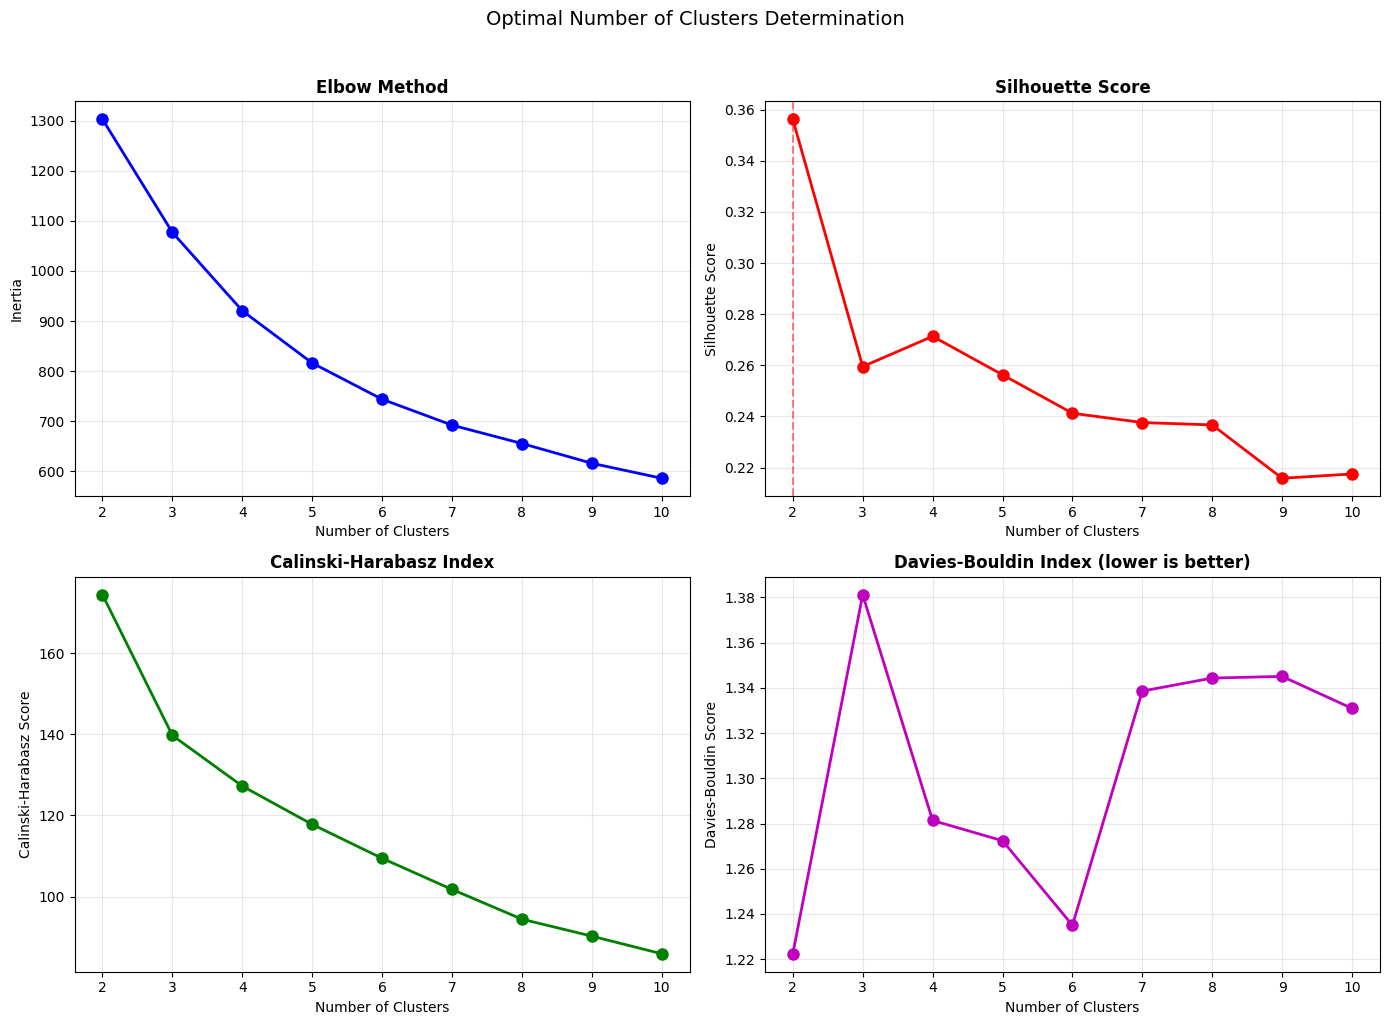


ПРИМЕНЕНИЕ 6 АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ

 K-Means...
    Silhouette: 0.3562
    Calinski-Harabasz: 174.45
    Davies-Bouldin: 1.2224

 Agglomerative...
    Silhouette: 0.2809
    Calinski-Harabasz: 135.10
    Davies-Bouldin: 1.4533

 Gaussian Mixture...
    Silhouette: 0.2214
    Calinski-Harabasz: 109.00
    Davies-Bouldin: 1.5617

 Spectral...
    Silhouette: 0.3672
    Calinski-Harabasz: 151.03
    Davies-Bouldin: 1.1056

 Birch...
    Silhouette: 0.3018
    Calinski-Harabasz: 134.93
    Davies-Bouldin: 1.3434

 DBSCAN...
   Кластеров: 2, Шум: 291
    Silhouette: -0.1621
    Calinski-Harabasz: 13.45
    Davies-Bouldin: 1.5403


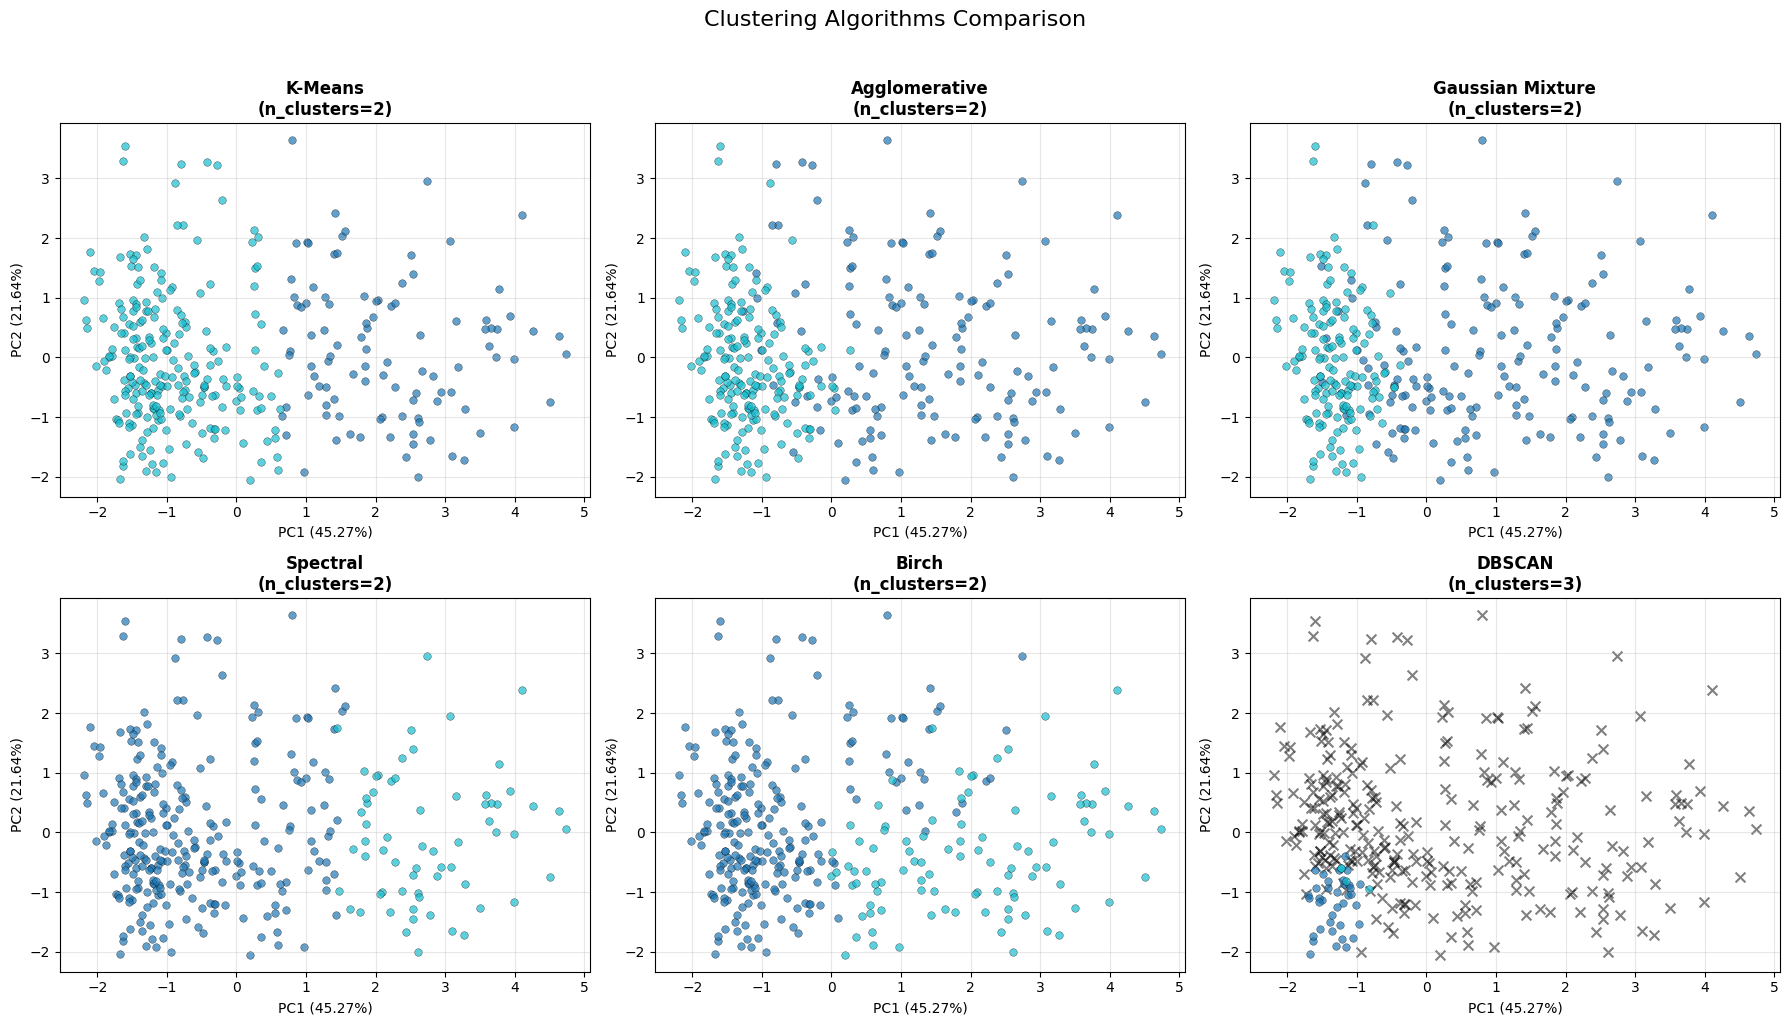


 Сравнение метрик:
                  silhouette  calinski_harabasz  davies_bouldin  n_clusters
Spectral              0.3672           151.0263          1.1056         2.0
K-Means               0.3562           174.4453          1.2224         2.0
Birch                 0.3018           134.9254          1.3434         2.0
Agglomerative         0.2809           135.0975          1.4533         2.0
Gaussian Mixture      0.2214           109.0010          1.5617         2.0
DBSCAN               -0.1621            13.4484          1.5403         3.0


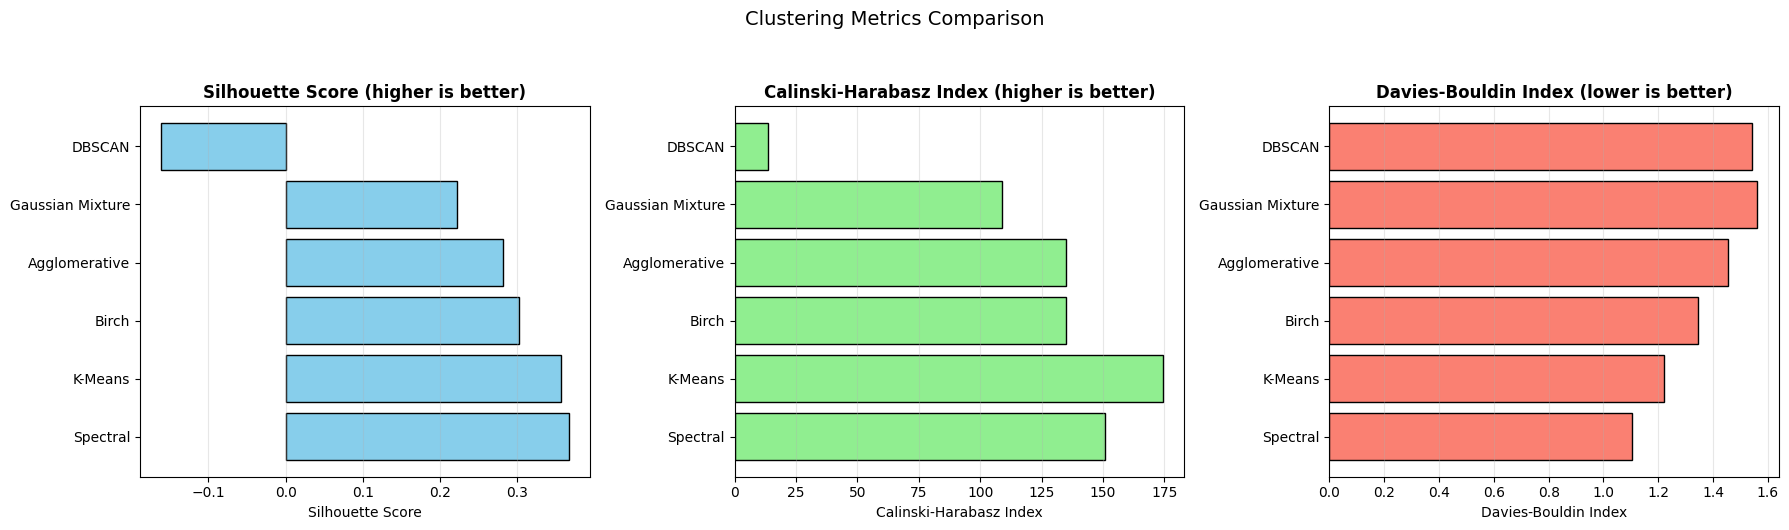

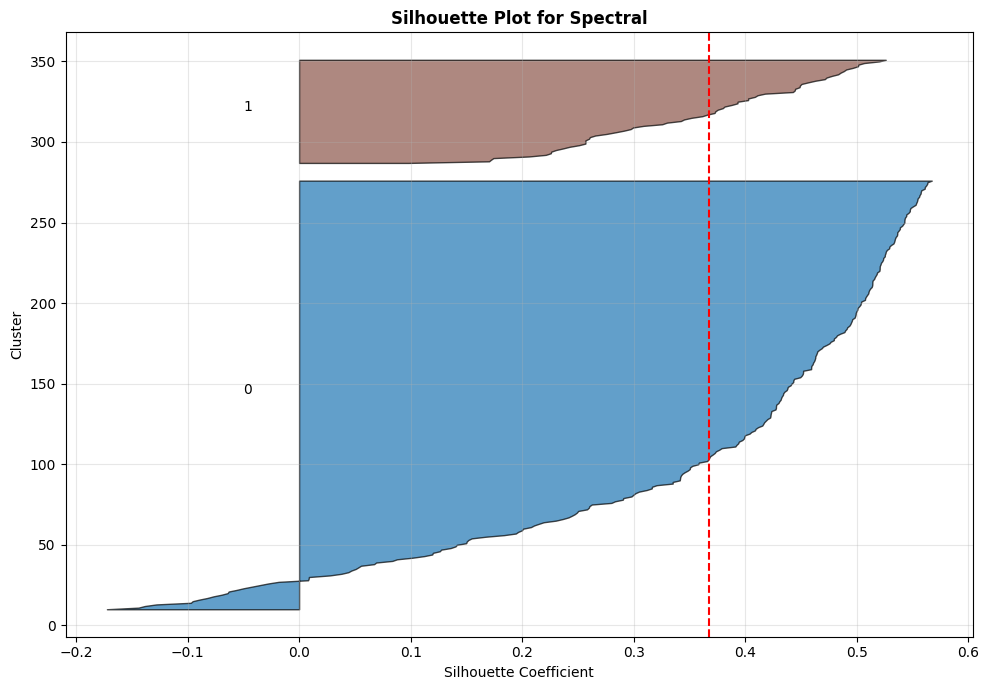

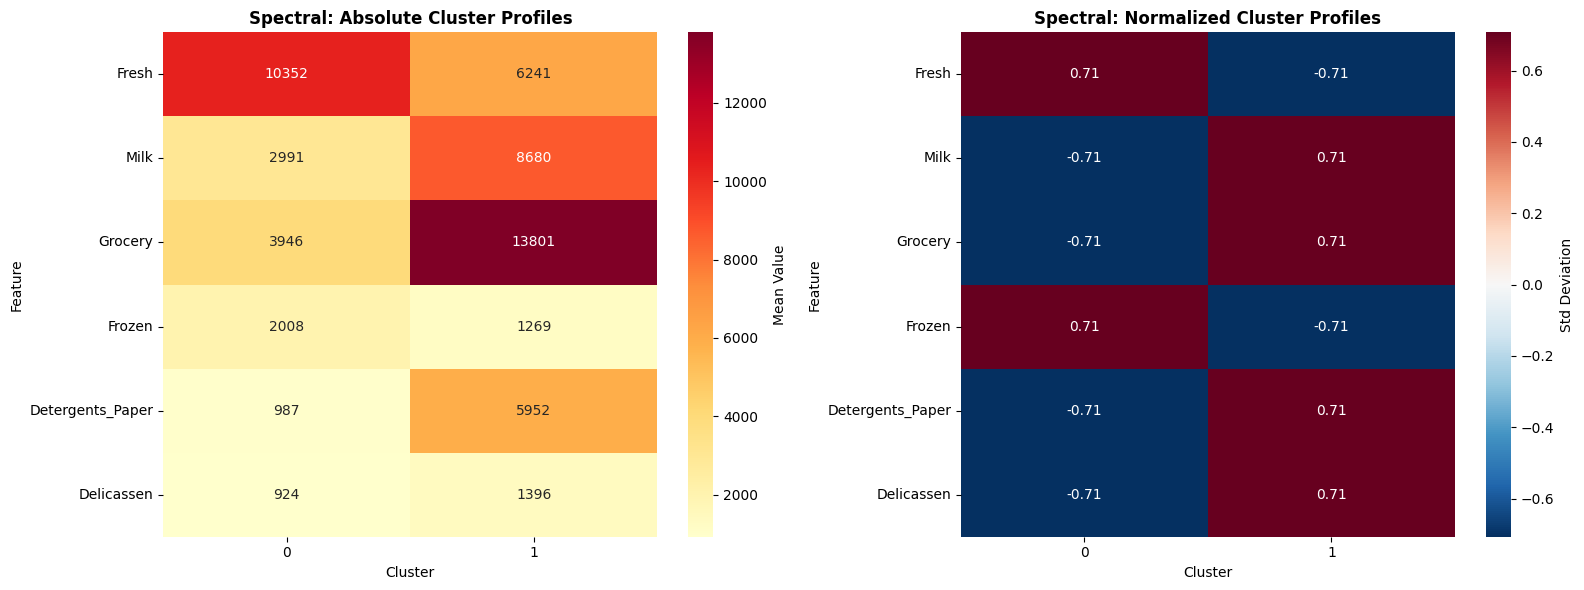


АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

Используем кластеры от Spectral как целевую переменную
Распределение: [267  65]

 Точность модели: 0.9700

 Отчет по классификации:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        80
           1       0.90      0.95      0.93        20

    accuracy                           0.97       100
   macro avg       0.95      0.96      0.95       100
weighted avg       0.97      0.97      0.97       100


 Кросс-валидация: [0.97014925 0.97014925 0.98484848 0.95454545 0.98484848]
   Среднее: 0.9729 (+/- 0.0226)


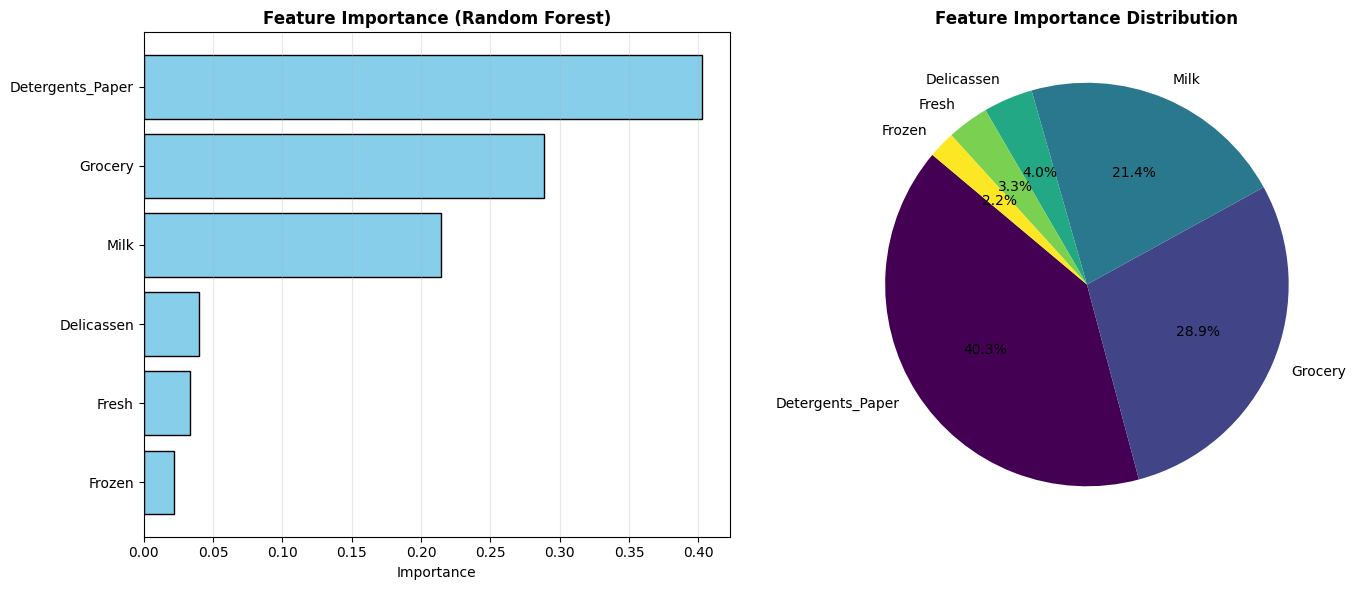


 Важность признаков:
         feature  importance
Detergents_Paper    0.402612
         Grocery    0.288592
            Milk    0.214123
      Delicassen    0.039639
           Fresh    0.033446
          Frozen    0.021589


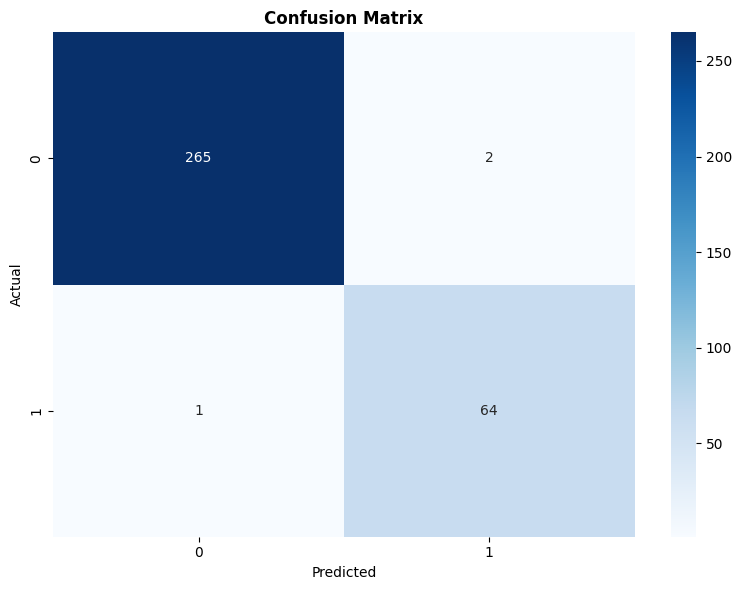


 Результаты сегментации сохранены в 'wholesale_segmented.csv'

 ИТОГОВЫЙ ОТЧЕТ


РЕЗУЛЬТАТЫ ПОЛНОЙ СЕГМЕНТАЦИИ:
     Оптимальное число кластеров: 2
     Лучший алгоритм: Spectral
     Silhouette Score: 0.3672
     Calinski-Harabasz: 151.03
     Davies-Bouldin: 1.1056
      
ВАЖНОСТЬ ПРИЗНАКОВ: 
     Detergents_Paper: 0.403
     Grocery: 0.289
     Milk: 0.214
     Delicassen: 0.040
     Fresh: 0.033
     Frozen: 0.022

 Сохраненные файлы:
    wholesale_segmented.csv - датасет с кластерами
    wholesale_with_anomalies.csv - датасет с метками аномалий
Содержимое лог-файла:
2026-03-15 03:13:30 - INFO - Data loaded: (332, 8)
2026-03-15 03:13:37 - INFO - Analysis completed successfully


In [3]:

lg.clear_log_file()

# ====================== 1. ПОЛНЫЙ АНАЛИЗ СЕГМЕНТАЦИИ ======================

print(" ПОЛНЫЙ АНАЛИЗ СЕГМЕНТАЦИИ")

# Создаем объект SegmentationAnalysis
seg_analysis = SegmentationAnalysis(file_path)
seg_analysis.df = df  # Используем загруженный датафрейм
seg_analysis.prepare_data()

# Определение оптимального числа кластеров
k_finder = OptimalKFinder(seg_analysis)
optimal_k_seg = k_finder.calculate_metrics()
k_finder.plot_metrics()

# Применение 6 алгоритмов кластеризации
clusterer = ClusteringAlgorithms(seg_analysis)
results_seg, metrics_seg = clusterer.apply_all()

# Визуализация результатов
visualizer = ClusteringVisualizer(seg_analysis, results_seg, metrics_seg)
visualizer.plot_clusters_pca()
metrics_df = visualizer.plot_metrics_comparison()
visualizer.plot_silhouette_analysis()
profiles = visualizer.plot_cluster_profiles()

# Анализ важности признаков
importance_analyzer = FeatureImportanceAnalyzer(seg_analysis, results_seg)
importance = importance_analyzer.analyze_importance()
importance_analyzer.plot_feature_importance()
importance_analyzer.plot_confusion_matrix()

# Сохранение результатов сегментации
best_algo = max(metrics_seg, key=lambda x: metrics_seg[x]['silhouette'])
df_with_clusters = seg_analysis.df.copy()
df_with_clusters['Cluster'] = results_seg[best_algo]
df_with_clusters.to_csv('wholesale_segmented.csv', index=False)
print(f"\n Результаты сегментации сохранены в 'wholesale_segmented.csv'")

my_results_dict['segmentation_results'] = {
    'best_algorithm': best_algo,
    'optimal_k': optimal_k_seg,
    'metrics': metrics_seg,
    'feature_importance': importance.to_dict() if importance is not None else None
}

# ====================== 2. ИТОГОВЫЙ ОТЧЕТ ======================

print("\n" + "=" * 80)
print(" ИТОГОВЫЙ ОТЧЕТ")
print("=" * 80)

print(f"""

РЕЗУЛЬТАТЫ ПОЛНОЙ СЕГМЕНТАЦИИ:
     Оптимальное число кластеров: {optimal_k_seg}
     Лучший алгоритм: {best_algo}
     Silhouette Score: {metrics_seg[best_algo]['silhouette']:.4f}
     Calinski-Harabasz: {metrics_seg[best_algo]['calinski_harabasz']:.2f}
     Davies-Bouldin: {metrics_seg[best_algo]['davies_bouldin']:.4f}

ВАЖНОСТЬ ПРИЗНАКОВ: """)

if importance is not None:
    for _, row in importance.iterrows():
        print(f"     {row['feature']}: {row['importance']:.3f}")

print("\n Сохраненные файлы:")
print("    wholesale_segmented.csv - датасет с кластерами")
print("    wholesale_with_anomalies.csv - датасет с метками аномалий")

lg.log_event("INFO", "Analysis completed successfully")
lg.read_log_file()
